# 5. NTv3 post-trained models: annotation and tracks

NTv3's `post` checkpoints were fine-tuned on functional genomics data and are conditioned on
the **species** the DNA comes from. Besides embeddings they can

- **annotate** a sequence: for every base, the probability that it lies in a gene, exon,
  intron, promoter, UTR, ... (`annotate_sequence`, 21 element types),
- **predict experimental tracks**: RNA-seq, ChIP-seq, ATAC/DNase, CAGE, ... coverage
  (`predict_tracks`; 7362 tracks for human).

Predictions cover only the **central 37.5%** of the input window; the rest is context. We use
a 32 kb window of hg38 centred on *HBB* (fetched from the UCSC API, so this needs internet).

> Run the series in order the first time: notebook 01 explains the setup. Every notebook
> starts by connecting to the services through `tutorial_utils.py` next to it; a service
> that isn't running is skipped.

In [1]:
from tutorial_utils import connect, fetch_hg38

ntv3 = connect(["ntv3"])["ntv3"]
species = ntv3.call("list_species", checkpoint="100m-post")
print(
    len(species["species"]),
    "species; with tracks:",
    [s["name"] for s in species["species"] if s["num_tracks"]],
)
print(
    len(species["annotation_elements"]),
    "annotation elements:",
    ", ".join(species["annotation_elements"]),
)

server http://localhost | token set: True | up: ntv3


24 species; with tracks: ['arabidopsis_thaliana', 'drosophila_melanogaster', 'glycine_max', 'gossypium_hirsutum', 'human', 'mouse', 'oryza_sativa', 'triticum_aestivum', 'zea_mays']
21 annotation elements: protein_coding_gene, lncRNA, exon, intron, splice_donor, splice_acceptor, CTCF-bound, polyA_signal, enhancer_Tissue_specific, enhancer_Tissue_invariant, promoter_Tissue_specific, promoter_Tissue_invariant, 5UTR+, 5UTR-, 3UTR+, 3UTR-, skipped_exon, always_on_exon, start_codon, stop_codon, ORF


In [2]:
# HBB (hg38, minus strand): chr11:5,225,464-5,227,071; its transcription start is the right end.
CHROM, GENE_START, GENE_END = "chr11", 5_225_464, 5_227_071
HBB_EXONS = [(5_225_464, 5_225_726), (5_226_577, 5_226_799), (5_226_930, 5_227_071)]
center = (GENE_START + GENE_END) // 2
WIN_START = center - 16_384
window = fetch_hg38(CHROM, WIN_START, center + 16_384)
print(f"{CHROM}:{WIN_START:,}-{WIN_START + len(window):,} ({len(window):,} bp)")

chr11:5,209,883-5,242,651 (32,768 bp)


## Genome annotation

`annotate_sequence` returns per-bin probabilities for the requested elements. Grey bands
below are the real HBB exons from the hg38 annotation; the model sees only DNA and species.

In [3]:
BIN = 16
ELEMENTS = ["protein_coding_gene", "exon", "intron", "3UTR-"]
ann = ntv3.call(
    "annotate_sequence",
    sequence=window,
    checkpoint="100m-post",
    species="human",
    bin_size=BIN,
    elements=ELEMENTS,
)
x = [WIN_START + ann["region_start"] + i * BIN for i in range(len(ann["probabilities"]["exon"]))]


def mean_prob(elem, lo, hi):
    vals = [p for xi, p in zip(x, ann["probabilities"][elem]) if lo <= xi < hi]
    return sum(vals) / len(vals)


for name, (lo, hi) in [
    ("exon 3", HBB_EXONS[0]),
    ("intron 2", (HBB_EXONS[0][1] + 50, HBB_EXONS[1][0] - 50)),
    ("exon 2", HBB_EXONS[1]),
    ("exon 1", HBB_EXONS[2]),
    ("5 kb outside", (GENE_END + 4000, GENE_END + 5000)),
]:
    print(
        f"{name:13s} exon={mean_prob('exon', lo, hi):.2f}  intron={mean_prob('intron', lo, hi):.2f}"
    )

exon 3        exon=0.89  intron=0.28
intron 2      exon=0.45  intron=0.96
exon 2        exon=0.87  intron=0.25
exon 1        exon=0.83  intron=0.19
5 kb outside  exon=0.03  intron=0.08


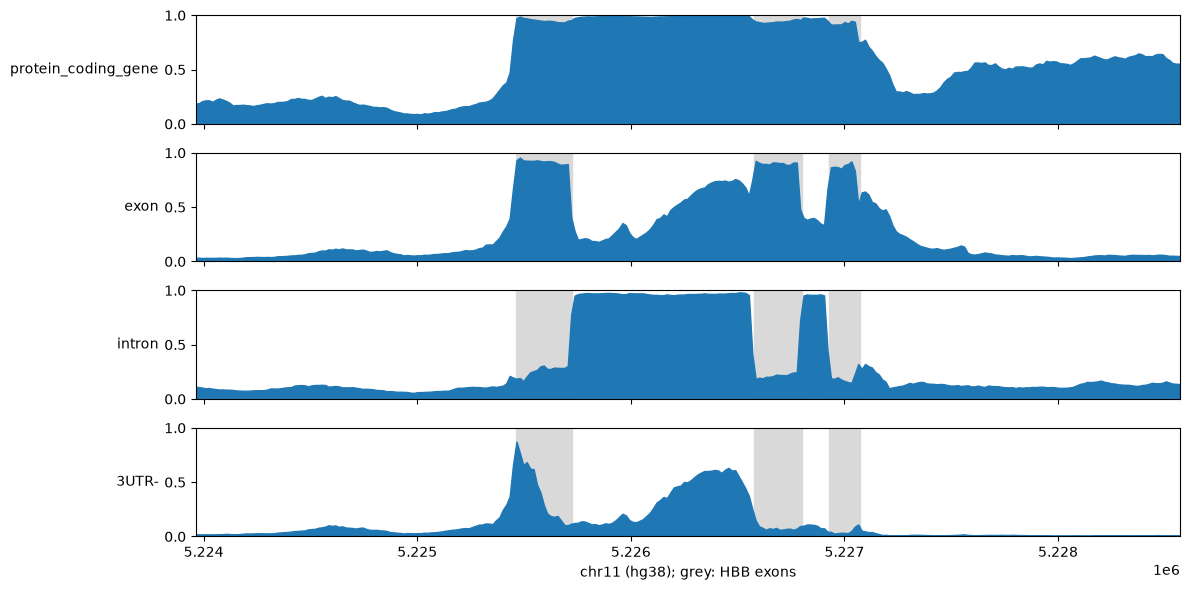

In [4]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(len(ELEMENTS), 1, figsize=(12, 6), sharex=True)
    for ax, elem in zip(axes, ELEMENTS):
        for lo, hi in HBB_EXONS:
            ax.axvspan(lo, hi, color="0.85")
        ax.fill_between(x, ann["probabilities"][elem], color="tab:blue")
        ax.set_ylim(0, 1)
        ax.set_ylabel(elem, rotation=0, ha="right", va="center")
    axes[-1].set_xlim(GENE_START - 1500, GENE_END + 1500)
    axes[-1].set_xlabel(f"{CHROM} (hg38); grey: HBB exons")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("(matplotlib is not installed)")

## Experimental tracks

`list_tracks` pages through the track ids of a species (`contains` filters them). The model
ships ids only; the prefix tells the source: `ENCSR...` ENCODE, `CNhs...` FANTOM5 CAGE,
`GTEX-...` GTEx RNA-seq, and so on. CAGE measures transcription starts; FANTOM5 CAGE tracks
come in pairs per strand (`_P` plus, `_M` minus). HBB is on the minus strand, so we average
minus-strand CAGE tracks and look for a peak at its transcription start.

In [5]:
listing = ntv3.call("list_tracks", species="human", contains="CNhs", limit=200)
minus = [t for t in listing["track_ids"] if t.endswith("_M")][:32]
print(listing["total"], "CAGE track ids; using", len(minus), "minus-strand tracks")

TRACK_BIN = 32
pred = ntv3.call(
    "predict_tracks",
    sequence=window,
    track_ids=minus,
    checkpoint="100m-post",
    species="human",
    bin_size=TRACK_BIN,
)
values = list(pred["tracks"].values())
mean_signal = [sum(col) / len(col) for col in zip(*values)]
tx = [WIN_START + pred["region_start"] + i * TRACK_BIN for i in range(len(mean_signal))]
peak = max(range(len(mean_signal)), key=mean_signal.__getitem__)
print(
    f"strongest predicted CAGE signal at {CHROM}:{tx[peak]:,}; HBB transcription start {GENE_END:,} (distance {tx[peak] - GENE_END:+,} bp)"
)

1276 CAGE track ids; using 32 minus-strand tracks


strongest predicted CAGE signal at chr11:5,227,067; HBB transcription start 5,227,071 (distance -4 bp)


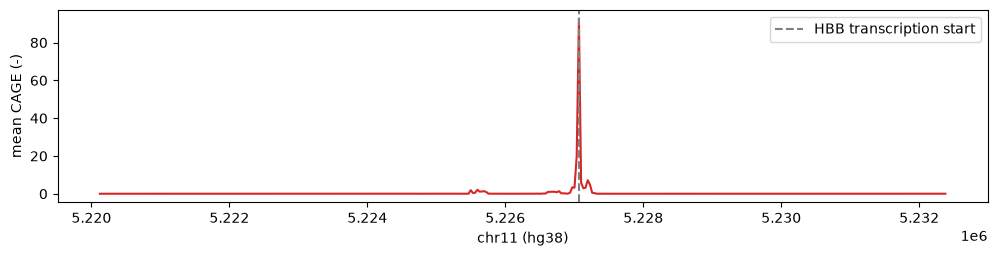

In [6]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.plot(tx, mean_signal, color="tab:red")
    ax.axvline(GENE_END, color="0.5", linestyle="--", label="HBB transcription start")
    ax.set_xlabel(f"{CHROM} (hg38)")
    ax.set_ylabel("mean CAGE (-)")
    ax.legend()
    plt.show()
except ImportError:
    print("(matplotlib is not installed)")

Track values are the model's predicted coverage on its own scale, not calibrated read
counts. For a specific cell type, pick its tracks (look the ids up at ENCODE or FANTOM5)
instead of averaging.

**Next:** [6. OpenAI-compatible gateway](06_openai_gateway.ipynb)